In [14]:
import os
import json
import torch
import numpy as np
import matplotlib.pyplot as plt

import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader

from pipeline import reader, preprocessor, dataset
from model import LSM_cnn
from utils import drawAUC_TwoClass, precis, recall, f1

**Configuration**

In [15]:
config = {
    'feature_path': 'Data/mojokerto/feature11/',
    'label_path': 'Data/mojokerto/label/label1.tif',
    'output_dir': 'Hasil/mojokerto/feature11',
    'window_size': 15,
    'lr': 0.001,
    'batch_size': 128,
    'epochs': 500
}

os.makedirs(config['output_dir'], exist_ok=True)

## Preprocessing

**Validate Data Consistency**

In [16]:
reader.validate_consistency(config['feature_path'], config['label_path'])

Data consistency check passed.


True

**Load and Normalize Features**

In [17]:
padded_features = []
norm_params = {}
n = config['window_size'] // 2

feature_files = sorted([f for f in os.listdir(config['feature_path']) if f.lower().endswith('.tif')])

for i, feature_name in enumerate(feature_files, 1):
    img = reader.read_data_from_tif(os.path.join(config['feature_path'], feature_name))
    norm_img, norm_param = preprocessor.normalize_min_max(img)
    norm_params[feature_name] = norm_param
    padded_img = preprocessor.apply_padding(norm_img, n, pad_value=0)
    padded_features.append(padded_img)

# Save normalization parameters
with open(os.path.join(config['output_dir'], 'norm_params.json'), 'w') as f:
    json.dump(norm_params, f, indent=4)

feature_block = np.array(padded_features)
print(f"Feature block created successfully: {feature_block.shape}")

Feature block created successfully: (11, 730, 388)


**Process Label Data**

In [18]:
label_img = reader.read_data_from_tif(config['label_path'])
padded_label = preprocessor.apply_padding(label_img, n, pad_value=0.1)
print(f"Label processed: {padded_label.shape}")

Label processed: (730, 388)


**Create CNN Dataset**

In [19]:
train_x, train_y, val_x, val_y = dataset.get_CNN_data(feature_block, padded_label, config['window_size'])

print(f"Training data: {train_x.shape[0]} samples")
print(f"Validation data: {val_x.shape[0]} samples")
print(f"Feature shape: {train_x.shape[1:]}")

Training data: 420 samples
Validation data: 180 samples
Feature shape: (11, 15, 15)


**Data Loaders**

In [20]:
train_dataset = TensorDataset(torch.from_numpy(train_x).float(), torch.from_numpy(train_y).float())
train_loader = DataLoader(dataset=train_dataset, batch_size=config['batch_size'], shuffle=True)

val_dataset = TensorDataset(torch.from_numpy(val_x).float(), torch.from_numpy(val_y).float())
val_loader = DataLoader(dataset=val_dataset, batch_size=config['batch_size'], shuffle=False)

print(f"  Training batches: {len(train_loader)}")
print(f"  Validation batches: {len(val_loader)}")

  Training batches: 4
  Validation batches: 2


In [21]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = LSM_cnn(in_chanel=feature_block.shape[0]).to(device)
criterion = nn.CrossEntropyLoss().to(device)
optimizer = optim.SGD(model.parameters(), lr=config['lr'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.1)

print(f"Model initialized with {feature_block.shape[0]} input channels")

Using device: cuda
Model initialized with 11 input channels


## Training

In [22]:
max_acc = 0.0  
record = {
    "train": {"acc": [], "loss": [], "precision": [], "recall": [], "f1": []}, 
    "val": {"acc": [], "loss": [], "precision": [], "recall": [], "f1": []},
    "best_epoch": 0
}

for epoch in range(config['epochs']):
    model.train()
    train_loss, train_acc = 0.0, 0.0
    train_outputs_list, train_labels_list, train_preds_list = [], [], []
    
    for images, target in train_loader:
        images, target = images.to(device), target.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        _, preds = torch.max(outputs.data, 1)
        loss = criterion(outputs, target.squeeze().long())
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        train_acc += (preds.squeeze() == target.squeeze()).sum().item()
        train_outputs_list.extend(outputs.detach().cpu().numpy())
        train_labels_list.extend(target.cpu().numpy())
        train_preds_list.extend(preds.cpu().numpy())
    
    # training metrics
    avg_train_acc = train_acc / len(train_dataset)
    avg_train_loss = train_loss / len(train_loader)
    train_labels_np = np.array(train_labels_list)
    train_preds_np = np.array(train_preds_list)
    train_precision = precis(train_labels_np, train_preds_np)
    train_recall = recall(train_labels_np, train_preds_np)
    train_f1 = f1(train_labels_np, train_preds_np)
    
    # validasi
    model.eval()
    val_loss, val_acc = 0.0, 0.0
    val_outputs_list, val_labels_list, val_preds_list = [], [], []
    
    with torch.no_grad():
        for images, target in val_loader:
            images, target = images.to(device), target.to(device)
            outputs = model(images)
            loss = criterion(outputs, target.squeeze().long())
            _, preds = torch.max(outputs.data, 1)
            
            val_loss += loss.item()
            val_acc += (preds.squeeze() == target.squeeze()).sum().item()
            val_outputs_list.extend(outputs.detach().cpu().numpy())
            val_labels_list.extend(target.cpu().numpy())
            val_preds_list.extend(preds.cpu().numpy())
    
    # metrics validasi
    avg_val_acc = val_acc / len(val_dataset)
    avg_val_loss = val_loss / len(val_loader)
    val_labels_np = np.array(val_labels_list)
    val_preds_np = np.array(val_preds_list)
    val_precision = precis(val_labels_np, val_preds_np)
    val_recall = recall(val_labels_np, val_preds_np)
    val_f1 = f1(val_labels_np, val_preds_np)
    
    print(f'Epoch [{epoch + 1:03d}/{config["epochs"]:03d}]')
    print(f'Train - Acc: {avg_train_acc:.6f} | Loss: {avg_train_loss:.6f} | Precision: {train_precision:.6f} | Recall: {train_recall:.6f} | F1: {train_f1:.6f}')
    print(f'Val   - Acc: {avg_val_acc:.6f} | Loss: {avg_val_loss:.6f} | Precision: {val_precision:.6f} | Recall: {val_recall:.6f} | F1: {val_f1:.6f}')
    
    if avg_val_acc > max_acc:
        print(f'BEST MODEL! Val acc meningkat ({max_acc:.6f} --> {avg_val_acc:.6f}). Menyimpan model...')
        max_acc = avg_val_acc
        record["best_epoch"] = epoch + 1
        torch.save(model.state_dict(), os.path.join(config['output_dir'], 'best.pth'))
        
        # AUC plots 
        score_array_val = np.array(val_outputs_list)
        score_array_train = np.array(train_outputs_list)
        drawAUC_TwoClass(val_labels_list, score_array_val[:, 0], os.path.join(config['output_dir'], 'val_AUC.png'))
        drawAUC_TwoClass(train_labels_list, score_array_train[:, 0], os.path.join(config['output_dir'], 'train_AUC.png'))
    
    # Record all metrics
    record["train"]["acc"].append(avg_train_acc)
    record["train"]["loss"].append(avg_train_loss)
    record["train"]["precision"].append(train_precision)
    record["train"]["recall"].append(train_recall)
    record["train"]["f1"].append(train_f1)
    
    record["val"]["acc"].append(avg_val_acc)
    record["val"]["loss"].append(avg_val_loss)
    record["val"]["precision"].append(val_precision)
    record["val"]["recall"].append(val_recall)
    record["val"]["f1"].append(val_f1)
    scheduler.step()

print(f"\nBest model saved at epoch {record['best_epoch']} with max_acc: {max_acc:.6f}")

Epoch [001/500]
Train - Acc: 0.497619 | Loss: 1.000418 | Precision: 0.500000 | Recall: 0.535714 | F1: 0.517241
Val   - Acc: 0.405556 | Loss: 0.693256 | Precision: 0.500000 | Recall: 0.661111 | F1: 0.569378
BEST MODEL! Val acc meningkat (0.000000 --> 0.405556). Menyimpan model...
Epoch [002/500]
Train - Acc: 0.559524 | Loss: 0.901606 | Precision: 0.500000 | Recall: 0.554762 | F1: 0.525959
Val   - Acc: 0.516667 | Loss: 0.692578 | Precision: 0.500000 | Recall: 0.061111 | F1: 0.108911
BEST MODEL! Val acc meningkat (0.405556 --> 0.516667). Menyimpan model...
Epoch [003/500]
Train - Acc: 0.607143 | Loss: 0.782920 | Precision: 0.500000 | Recall: 0.492857 | F1: 0.496403
Val   - Acc: 0.511111 | Loss: 0.690775 | Precision: 0.500000 | Recall: 0.011111 | F1: 0.021739
Epoch [004/500]
Train - Acc: 0.583333 | Loss: 0.834325 | Precision: 0.500000 | Recall: 0.564286 | F1: 0.530201
Val   - Acc: 0.527778 | Loss: 0.689694 | Precision: 0.500000 | Recall: 0.027778 | F1: 0.052632
BEST MODEL! Val acc meningka

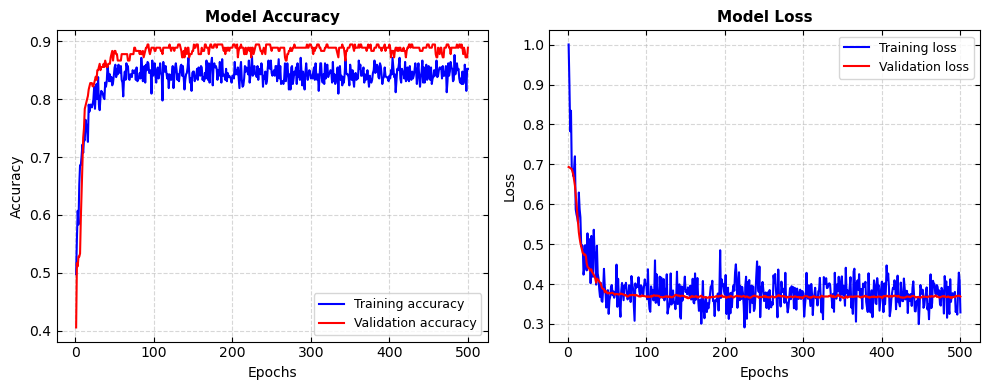

In [23]:
plt.figure(figsize=(10, 4))
epochs_range = range(1, len(record["train"]["acc"]) + 1)

# acc
plt.subplot(1, 2, 1) 
plt.plot(epochs_range, record["train"]["acc"], 'b-', linewidth=1.5, label='Training accuracy')
plt.plot(epochs_range, record["val"]["acc"], 'r-', linewidth=1.5, label='Validation accuracy')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Accuracy', fontsize=10)
plt.title('Model Accuracy', fontsize=11, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(direction='in', top=True, bottom=True, left=True, right=True)

# Loss
plt.subplot(1, 2, 2) 
plt.plot(epochs_range, record["train"]["loss"], 'b-', linewidth=1.5, label='Training loss')
plt.plot(epochs_range, record["val"]["loss"], 'r-', linewidth=1.5, label='Validation loss')
plt.xlabel('Epochs', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.title('Model Loss', fontsize=11, fontweight='bold')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tick_params(direction='in', top=True, bottom=True, left=True, right=True)

plt.tight_layout()
plt.savefig(os.path.join(config['output_dir'], 'training_metrics.png'), dpi=300, bbox_inches='tight')
plt.show()

In [24]:
# Save record to JSON
with open(os.path.join(config['output_dir'], 'record.json'), 'w') as f:
    json.dump(record, f, indent=4)

print("Training record saved to record.json")

Training record saved to record.json


**Save Latest Model**

In [25]:
torch.save(model.state_dict(), os.path.join(config['output_dir'], 'latest.pth'))
print("Latest model saved to latest.pth")

Latest model saved to latest.pth


In [26]:
print(f"\nbest Model Saved at Epoch: {record['best_epoch']}")

print(f"\nFinal Training Metrics")
print(f"Accuracy:  {record['train']['acc'][-1]*100:.2f}%")
print(f"Loss:      {record['train']['loss'][-1]:.4f}")
print(f"Precision: {record['train']['precision'][-1]*100:.2f}%")
print(f"Recall:    {record['train']['recall'][-1]*100:.2f}%")
print(f"F1-Score:  {record['train']['f1'][-1]*100:.2f}%")

print(f"\nFinal Validation Metrics")
print(f"Accuracy:  {record['val']['acc'][-1]*100:.2f}%")
print(f"Loss:      {record['val']['loss'][-1]:.4f}")
print(f"Precision: {record['val']['precision'][-1]*100:.2f}%")
print(f"Recall:    {record['val']['recall'][-1]*100:.2f}%")
print(f"F1-Score:  {record['val']['f1'][-1]*100:.2f}%")


best Model Saved at Epoch: 92

Final Training Metrics
Accuracy:  85.24%
Loss:      0.3288
Precision: 50.00%
Recall:    52.38%
F1-Score:  51.16%

Final Validation Metrics
Accuracy:  88.89%
Loss:      0.3685
Precision: 50.00%
Recall:    48.89%
F1-Score:  49.44%
